
===== SVM BEFORE TUNING =====
Accuracy: 0.8878048780487805
              precision    recall  f1-score   support

           0       0.93      0.83      0.88       102
           1       0.85      0.94      0.89       103

    accuracy                           0.89       205
   macro avg       0.89      0.89      0.89       205
weighted avg       0.89      0.89      0.89       205


Best Parameters: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}

===== SVM AFTER TUNING =====
Accuracy: 0.9853658536585366
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



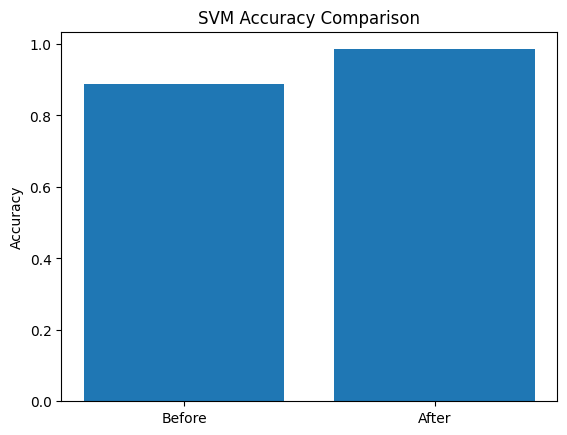

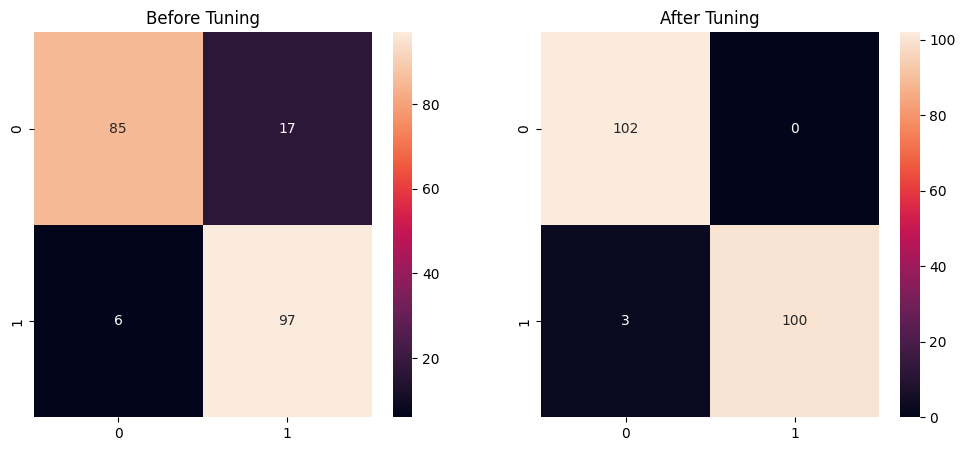

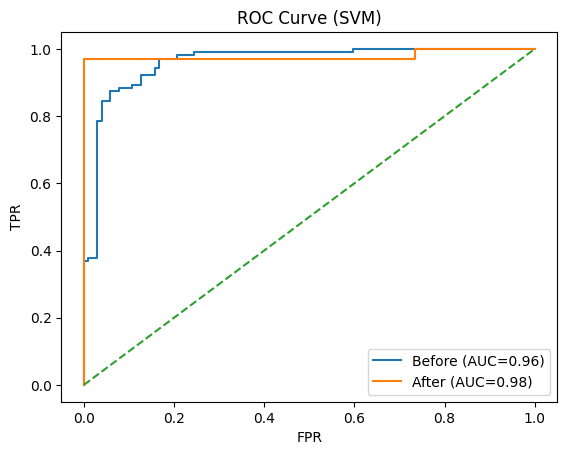

In [2]:
# ==========================================
# STEP 1: Import Libraries
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import StandardScaler

# ==========================================
# STEP 2: Load Dataset
# ==========================================
df = pd.read_csv('/content/heart.csv')

X = df.drop("target", axis=1)
y = df["target"]

# ==========================================
# STEP 3: Preprocessing
# ==========================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

# ==========================================
# STEP 4: SVM BEFORE TUNING
# ==========================================
svm_before = SVC(probability=True)
svm_before.fit(X_train, y_train)

y_pred_before = svm_before.predict(X_test)
y_prob_before = svm_before.predict_proba(X_test)[:,1]

acc_before = accuracy_score(y_test, y_pred_before)

print("\n===== SVM BEFORE TUNING =====")
print("Accuracy:", acc_before)
print(classification_report(y_test, y_pred_before))

# ==========================================
# STEP 5: HYPERPARAMETER TUNING
# ==========================================
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 0.1, 0.01]
}

grid = GridSearchCV(SVC(probability=True),
                    param_grid,
                    cv=5,
                    scoring='accuracy')

grid.fit(X_train, y_train)

print("\nBest Parameters:", grid.best_params_)

svm_after = grid.best_estimator_

# ==========================================
# STEP 6: AFTER TUNING
# ==========================================
y_pred_after = svm_after.predict(X_test)
y_prob_after = svm_after.predict_proba(X_test)[:,1]

acc_after = accuracy_score(y_test, y_pred_after)

print("\n===== SVM AFTER TUNING =====")
print("Accuracy:", acc_after)
print(classification_report(y_test, y_pred_after))

# ==========================================
# STEP 7: ACCURACY COMPARISON
# ==========================================
plt.figure()
plt.bar(['Before', 'After'], [acc_before, acc_after])
plt.title("SVM Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

# ==========================================
# STEP 8: CONFUSION MATRIX
# ==========================================
fig, axes = plt.subplots(1,2, figsize=(12,5))

sns.heatmap(confusion_matrix(y_test, y_pred_before), annot=True, fmt='d', ax=axes[0])
axes[0].set_title("Before Tuning")

sns.heatmap(confusion_matrix(y_test, y_pred_after), annot=True, fmt='d', ax=axes[1])
axes[1].set_title("After Tuning")

plt.show()

# ==========================================
# STEP 9: ROC CURVE (COMBINED)
# ==========================================
fpr1, tpr1, _ = roc_curve(y_test, y_prob_before)
fpr2, tpr2, _ = roc_curve(y_test, y_prob_after)

auc1 = auc(fpr1, tpr1)
auc2 = auc(fpr2, tpr2)

plt.figure()
plt.plot(fpr1, tpr1, label=f"Before (AUC={auc1:.2f})")
plt.plot(fpr2, tpr2, label=f"After (AUC={auc2:.2f})")
plt.plot([0,1],[0,1],'--')

plt.title("ROC Curve (SVM)")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.show()